In [1]:
# This notebook contains numerical methods simulation for AI Agent Group Alignment through the Lens of Principal-Agent Problem Framework

# Library imports

import numpy as np

import matplotlib.pyplot as plt

# Numerical simulation

Two equations from the paper. Each agent has a latent norm $\theta_i$ (hidden) and an output $y_i$ (visible).

**1. Behaviour** - agents copy each other ($\alpha$) and the watched ones are pulled
toward the human norm ($\beta$):

$$y_i(t+1) = y_i(t) + \alpha\,[\bar y - y_i(t)] + \beta\,\omega_i\,[\bar r - y_i(t)]$$

**2. Internalisation** — an agent's latent norm slowly drifts toward its own past behaviour:

$$\theta_i(t+1) = \theta_i(t) + \eta\,[\,y_i(t) - \theta_i(t)\,]$$

Alignment means the latent norm is close to the human norm:
$S=\{\theta:|\theta-\bar r|\le\rho\}$.

The three experiments below ask: does the agent and principal values converge, how much principal oversight does it need and
how much internationalisation is required to ensure alignment even when observation is switched off.

In [7]:

N_agent, N_principal = int(100000), int(100)          
ALPHA, BETA, ETA = 0.10, 0.50, 0.01   
M, RHO = 0.05, 0.10              

rng_principal = np.random.default_rng(0) 
x = rng_principal.normal(1.0, 0.05, N_principal)
r = x - x.mean() + 1.0           
r_bar = r.mean()
assert r_bar == 1 

theta0 = np.random.default_rng(1).uniform(0.0, 1.0, N_agent)   

print(f"human norm  r_bar     = {r_bar:.3f}")
print(f"agents start at theta = {theta0.mean():.3f} without loss of generality")

human norm  r_bar     = 1.000
agents start at theta = 0.500 without loss of generality


In [ ]:

def simulate(alpha=ALPHA, beta=BETA, eta=ETA, m=M, T=1500, T_off=None, seed=2):
    """simulate() -> [mean y, mean theta, fraction of theta inside S]"""
    rng = np.random.default_rng(seed)
    y, theta = theta0.copy(), theta0.copy()
    omega = np.zeros(N_agent)
    omega[rng.choice(N_agent, int(m * N_agent), replace=False)] = 1.0     

    out = np.empty((T, 3))
    for t in range(T):
        if t == T_off:                       
            omega[:] = 0.0
            y = theta.copy()                 
        y     = y + alpha * (y.mean() - y) + beta * omega * (r_bar - y) 
        theta = theta + eta * (y - theta) 
        out[t] = y.mean(), theta.mean(), np.mean(np.abs(theta - r_bar) <= RHO)
    return out

def gap(run):      return abs(run[-1, 1] - r_bar)    


## 1. Does the swarm converge towards the human norm?

Compare the full model with the case $\beta=0$ — conformity only, no principal oversight.

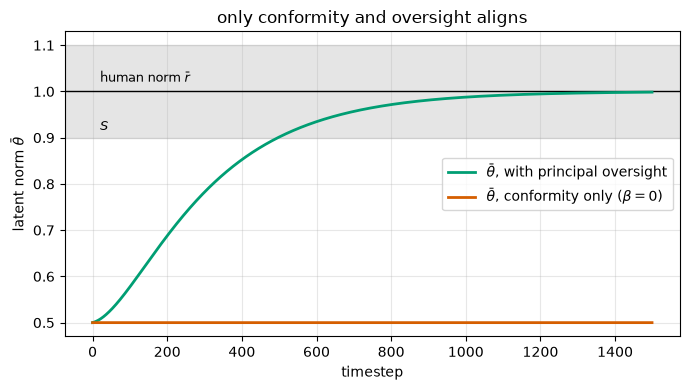

with oversight : theta = 0.9985,  100% of agents in S
conformity only: theta = 0.5000,  0% of agents in S


In [ ]:
full = simulate()                 
conf = simulate(beta=0.0)         

# Plotting
plt.figure(figsize=(7, 4))
plt.axhspan(r_bar - RHO, r_bar + RHO, color="grey", alpha=0.2)
plt.axhline(r_bar, color="k", lw=1)
plt.plot(full[:, 1], color="#009E73", lw=2, label=r"$\bar\theta$, with principal oversight")
plt.plot(conf[:, 1], color="#D55E00", lw=2, label=r"$\bar\theta$, conformity only ($\beta=0$)")
plt.text(20, r_bar + 0.02, r"human norm $\bar r$", fontsize=9)
plt.text(20, r_bar - RHO + 0.015, r"$S$", fontsize=9)
plt.xlabel("timestep"); plt.ylabel(r"latent norm $\bar\theta$")
plt.title("only conformity and oversight aligns")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"with oversight : theta = {full[-1,1]:.4f},  {100*full[-1,2]:.0f}% of agents in S")
print(f"conformity only: theta = {conf[-1,1]:.4f},  {100*conf[-1,2]:.0f}% of agents in S")

Conformity is mean-preserving — agent social norms make agents agree with each other, but it
cannot move the group average to align with human social norms. It needs the $\beta$ term to supply the human norm.

## 2. How many agents must be under principal observation?

This is the cost question. Sweep the watched fraction $m$, with and without conformity.

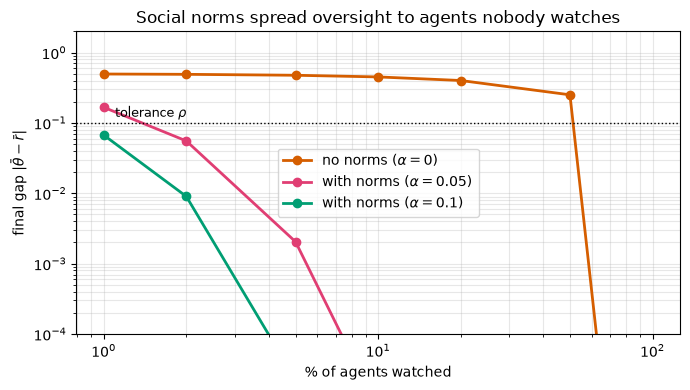

watching 2%  -> gap 0.0090 with norms, 0.4900 without


In [ ]:
ms = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.00] 
with_norms = [gap(simulate(m=m, T=2500)) for m in ms]
no_norms   = [gap(simulate(m=m, T=2500, alpha=0.0)) for m in ms]
lower_norms   = [gap(simulate(m=m, T=2500, alpha=0.05)) for m in ms]

# showing the effect of 3 norm values on the proportion of agents that must be watched as a function of final gap
plt.figure(figsize=(7, 4))
plt.plot(100*np.array(ms), no_norms,   "o-", color="#D55E00", lw=2, label=r"no norms ($\alpha=0$)")
plt.plot(100*np.array(ms), lower_norms, "o-", color="#E03E73", lw=2, label=r"with norms ($\alpha=0.05$)")
plt.plot(100*np.array(ms), with_norms, "o-", color="#009E73", lw=2, label=r"with norms ($\alpha=0.1$)")

plt.axhline(RHO, color="k", ls=":", lw=1); plt.text(1.1, RHO*1.2, r"tolerance $\rho$", fontsize=9)
plt.xscale("log"); plt.yscale("log"); plt.ylim(1e-4, 2)
plt.xlabel("% of agents watched"); plt.ylabel(r"final gap $|\bar\theta - \bar r|$")
plt.title("Social norms spread oversight to agents nobody watches")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

print(f"watching 2%  -> gap {with_norms[1]:.4f} with norms, {no_norms[1]:.4f} without")

Without norms, oversight only reaches the agents it touches, so the gap falls only as
fast as $m$ grows. With norms, watching a few per cent
is enough: the watched agents carry the human norm to the rest.

**This is the paper's central claim, and it holds.** (The axis stops at $10^{-4}$ because below
that the gap, the value is close to zero.)

## 3. What happens when oversight is turned off?

This tests the scenario where oversight runs until $t=600$ and then stops. Whether alignment survives depends on $\eta$, which tells us
how much of its own behaviour (previous output) an agent has absorbed.

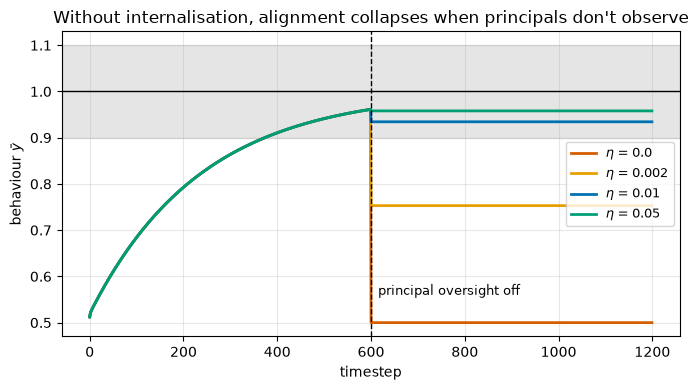

eta=0.0    y before switch = 0.961   after = 0.500
eta=0.01   y before switch = 0.961   after = 0.934


In [ ]:

plt.figure(figsize=(7, 4))
plt.axhspan(r_bar - RHO, r_bar + RHO, color="grey", alpha=0.2)
plt.axhline(r_bar, color="k", lw=1)
for eta, c in [(0.0, "#D55E00"), (0.002, "#E69F00"), (0.01, "#0072B2"), (0.05, "#009E73")]:
    run = simulate(eta=eta, T=1200, T_off=600)
    plt.plot(run[:, 0], color=c, lw=2, label=fr"$\eta$ = {eta}")
plt.axvline(600, color="k", ls="--", lw=1)
plt.text(615, 0.56, "principal oversight off", fontsize=9)
plt.xlabel("timestep"); plt.ylabel(r"behaviour $\bar y$")
plt.title("Without internalisation, alignment collapses when principals don't observe")
plt.legend(fontsize=9, loc="center right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

for eta in [0.0, 0.01]:
    run = simulate(eta=eta, T=1200, T_off=600)
    print(f"eta={eta:<5}  y before switch = {run[599,0]:.3f}   after = {run[-1,0]:.3f}")

At $\eta=0$ behaviour looks near-perfect while oversight is on, then falls straight back to its original behaviour at timestep = 600 when observation is withdrawn.
This means that agents were complying, not aligned. $\eta$ is what turns compliance into actual alignment.